# Making an XGBoost model for Scot-Free
The random forest model generated in the exploratory analysis is reasonably capable but is very memory-hungry. I am cheap and the free tiers of cloud-platforms are not RAM-rich. The plan is now to give /web_app a lighter-weight xgb model (may also perform better as well!)

In [ ]:
#This notebook follows a similar structure as ex_analysis.ipynb but has been streamlined to just generate the model without the fun extra analytical stuff. 


import polars as pl
import numpy as np
import time

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OrdinalEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.calibration import CalibratedClassifierCV
from sklearn.tree import DecisionTreeClassifier
from sklearn.experimental import enable_halving_search_cv
from sklearn.model_selection import HalvingGridSearchCV
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import StratifiedGroupKFold
from sklearn.model_selection import GroupShuffleSplit
from sklearn.metrics import brier_score_loss
from sklearn.metrics import d2_brier_score
from sklearn.inspection import partial_dependence
from xgboost import XGBClassifier
from xgboost import plot_importance
import matplotlib.pyplot as plt
import joblib



# config for max display of columns and rows
pl.Config.set_tbl_rows(100)
pl.Config.set_tbl_cols(100)
pl.Config.set_fmt_str_lengths(60)

today = time.strftime("%y%m%d")




murderdata_cleaned = pl.read_parquet(f'260302_cleanmurderdataarchive.parquet')

In [ ]:

murderdata_cleaned = murderdata_cleaned.select([
    'incident_id','incident_year','incident_month','incident_monthday','incident_hour','incident_weekday',
    'incident_yearday', 'report_date_flag','state_abbr','agency_type_name','population','suburban_area_flag',
    'population_group_desc','pop_sort_order','male_officer','male_civilian', 'male_total','female_officer',
    'female_civilian','female_total','officer_rate','employee_rate','county_name','msa_name','sex_code',
    'resident_status_code','age_range_low_num','age_range_high_num','age_decimal','victim_age_status',
    'ethnicity_name','race_desc','victim_type_name','criminal_act_name',
    'location_name','prop_destruction','taken_by_cops',
    'looted_remains','firearms','feet_and_fists','edged_weapon','vehicle_as_weapon','blunt_weapon',
    'weaponized_fire','weapons_unknown','choked_or_strangled','poison','other_weapon',
    'num_of_victims','num_of_killers','scot_free'
    ])



#make is_null columns for columns with missing data. XGB handles imputation natively but it would lose the "info of no-info" which might be helpful
null_columns = [ col for col in murderdata_cleaned.columns if murderdata_cleaned[col].has_nulls() ]
already_docced = [item for item in null_columns if 'incident_' in item] + [item for item in null_columns if 'age_' in item] #age and time already have null-markers
for ncol in already_docced:
    null_columns.remove(ncol)
newcols = []
for coln in null_columns:
    murderdata_cleaned = murderdata_cleaned.with_columns(
        pl.when( pl.col(coln).is_null()  ).then(1).otherwise(0).alias(f"{coln}_is_null")
    )
    newcols.append(f"{coln}_is_null")
#reorganize dataframe again so it looks nice
murderdata_cleaned = murderdata_cleaned.select([
    'incident_id','incident_year','incident_month','incident_monthday','incident_hour','incident_weekday','incident_yearday', 
    'report_date_flag','state_abbr','agency_type_name','population','suburban_area_flag',
    'population_group_desc','pop_sort_order','male_officer','male_civilian', 'male_total','female_officer',
    'female_civilian','female_total','officer_rate','employee_rate','county_name','msa_name','sex_code',
    'resident_status_code','age_range_low_num','age_range_high_num','age_decimal','victim_age_status',
    'ethnicity_name','race_desc','victim_type_name','criminal_act_name',
    'location_name','prop_destruction','taken_by_cops',
    'looted_remains','firearms','feet_and_fists','edged_weapon','vehicle_as_weapon','blunt_weapon',
    'weaponized_fire','weapons_unknown','choked_or_strangled','poison','other_weapon',
    'num_of_victims', 'num_of_killers'] + newcols + ['scot_free']
    )


X = murderdata_cleaned.drop('scot_free','incident_id')
y = murderdata_cleaned['scot_free']
inc_groups = murderdata_cleaned['incident_id']


#make categorical and numerical column lists for later analysis. 
# There are transformations/encodings in 260302_cleanmurderdataarchive.parquet made many cat variables binary already, still need to take care of the stragglers
cate_cols = [ col for col in X.columns if X[col].dtype == pl.datatypes.String ]
nume_cols = [ col for col in X.columns if X[col].name not in cate_cols]

#train/eval/holdout data split on incident_ids to prevent model from training on data from the same group (incident) that it tests on
prototrain_indices, holdout_indices = next(GroupShuffleSplit(n_splits=1,test_size=.15,random_state=1).split(X,y,inc_groups)) #little miffed that train_test_split doesn't have an option for this
X_prototrain, X_holdout = X[prototrain_indices], X[holdout_indices]
y_prototrain, y_holdout = y[prototrain_indices], y[holdout_indices]

inc_groups_prototrain = inc_groups[prototrain_indices]
inc_groups_holdout = inc_groups[holdout_indices]

#chained splits to give me roughly 70% train, 15% eval, 15% holdout
train_indices, eval_indices = next(GroupShuffleSplit(n_splits=1,test_size=.17,random_state=1).split(X_prototrain,y_prototrain,inc_groups_prototrain))
X_train, X_eval = X_prototrain[train_indices], X_prototrain[eval_indices]
y_train, y_eval = y_prototrain[train_indices], y_prototrain[eval_indices]

inc_groups_train = inc_groups_prototrain[train_indices]
inc_groups_eval = inc_groups_prototrain[eval_indices]

Rework random forest pipeline for XGB. Remove imputation and tweak encoding

In [3]:
group_kf = StratifiedGroupKFold(n_splits=5)


cate_trans = Pipeline(steps=[ # choosing ordinal encoding over XGB's native categorical handling mostly for ease of use
    ('encoder', OrdinalEncoder(handle_unknown='use_encoded_value',unknown_value= np.nan))
])

preprocessor = ColumnTransformer(transformers=[
    #('num_prepro',  nume_trans, nume_cols ),
    ('cat_prepro', cate_trans, cate_cols )],
    remainder = 'passthrough')


xgboost_class = XGBClassifier(n_jobs=None)

xgboost_cal = CalibratedClassifierCV(
    XGBClassifier(n_jobs=None), #XGB docs imply that it's faster to have the classifier hog all the cores simultaneously
    cv = 4, #could potentially set-up a groupkfold CV scheme here if needed. But for prob-calibration it's probably fine as is
    method = 'isotonic', #try with 'sigmoid' too
    ensemble = True, # False is faster-- change if needed
    n_jobs=1
)


xgboost_pipe_cal = make_pipeline(preprocessor,xgboost_cal)
xgboost_pipe_class = make_pipeline(preprocessor,xgboost_class)


In [79]:

params_grid_cal = {"calibratedclassifiercv__method" : ['sigmoid','isotonic'],
                'calibratedclassifiercv__estimator__booster' : ['gbtree'],
                'calibratedclassifiercv__estimator__eta' : [.01, .1],
                'calibratedclassifiercv__estimator__max_depth' : [3, 6] ,
                'calibratedclassifiercv__estimator__n_estimators' : [100,200,500],
                'calibratedclassifiercv__estimator__subsample' : [.5,1],
                'calibratedclassifiercv__estimator__colsample_bytree' : [.7, 1],
                'calibratedclassifiercv__estimator__min_child_weight' : [1, 5],
                'calibratedclassifiercv__estimator__gamma' : [0, 3]
                } 


params_grid_class = {'xgbclassifier__booster' : ['gbtree'],
                'xgbclassifier__eta' : [.01, .1],
                'xgbclassifier__max_depth' : [3,6] ,
                'xgbclassifier__n_estimators' : [100,200,500],
                'xgbclassifier__subsample' : [.5,1],
                'xgbclassifier__colsample_bytree' : [.7, 1],
                'xgbclassifier__min_child_weight' : [1, 5],
                'xgbclassifier__gamma' : [0, 3]
                }

halvesearch_cal = HalvingGridSearchCV(
    xgboost_pipe_cal,
    params_grid_cal,
    scoring = 'd2_brier_score',
    cv=group_kf,
    error_score='raise', 
    n_jobs = 1,
    random_state = 1).fit(X_train,y_train,groups=inc_groups_train)

halvesearch_class = HalvingGridSearchCV(    
    xgboost_pipe_class,
    params_grid_class,
    scoring = 'd2_brier_score',
    cv=group_kf,
    error_score='raise', 
    n_jobs = 1,
    random_state = 1).fit(X_train,y_train,groups=inc_groups_train)

/Users/zed/miniforge3/envs/scotfree/lib/python3.13/site-packages/sklearn/metrics/_classification.py:3988: RuntimeWarning: divide by zero encountered in divide
  return float(1 - brier_score / brier_score_null)
/Users/zed/miniforge3/envs/scotfree/lib/python3.13/site-packages/sklearn/metrics/_classification.py:3988: RuntimeWarning: divide by zero encountered in divide
  return float(1 - brier_score / brier_score_null)
/Users/zed/miniforge3/envs/scotfree/lib/python3.13/site-packages/sklearn/metrics/_classification.py:3988: RuntimeWarning: divide by zero encountered in divide
  return float(1 - brier_score / brier_score_null)
/Users/zed/miniforge3/envs/scotfree/lib/python3.13/site-packages/sklearn/metrics/_classification.py:3988: RuntimeWarning: divide by zero encountered in divide
  return float(1 - brier_score / brier_score_null)


KeyboardInterrupt: 

In [42]:
print("WITH CALIBRATOR" )
print("best params:" )
print(halvesearch_cal.best_params_)
print("best score:")
print(halvesearch_cal.best_score_)

print("SANS CALIBRATOR" )
print("best params:" )
print(halvesearch_class.best_params_)
print("best score:")
print(halvesearch_class.best_score_)


WITH CALIBRATOR
best params:
{'calibratedclassifiercv__estimator__booster': 'gbtree', 'calibratedclassifiercv__estimator__colsample_bytree': 1, 'calibratedclassifiercv__estimator__eta': 0.1, 'calibratedclassifiercv__estimator__gamma': 3, 'calibratedclassifiercv__estimator__max_depth': 6, 'calibratedclassifiercv__estimator__min_child_weight': 5, 'calibratedclassifiercv__estimator__n_estimators': 200, 'calibratedclassifiercv__estimator__subsample': 0.5, 'calibratedclassifiercv__method': 'sigmoid'}
best score:
0.05940061575406001
SANS CALIBRATOR
best params:
{'xgbclassifier__booster': 'gbtree', 'xgbclassifier__colsample_bytree': 1, 'xgbclassifier__eta': 0.01, 'xgbclassifier__gamma': 0, 'xgbclassifier__max_depth': 3, 'xgbclassifier__min_child_weight': 5, 'xgbclassifier__n_estimators': 200, 'xgbclassifier__subsample': 0.5}
best score:
0.0777588129043579


In [44]:


fullmodel = halvesearch_class.best_estimator_
#print(fullmodel.classes_)
y_estim = fullmodel.predict_proba(X_holdout)
brier = brier_score_loss(y_holdout,y_estim)
d2_brier = d2_brier_score(y_holdout,y_estim)
print(f"brier score: {brier}")
print(f"D^2 brier: {d2_brier}")

fullmodel = halvesearch_cal.best_estimator_
#print(fullmodel.classes_)
y_estim = fullmodel.predict_proba(X_holdout)
brier = brier_score_loss(y_holdout,y_estim)
d2_brier = d2_brier_score(y_holdout,y_estim)
print(f"brier score: {brier}")
print(f"D^2 brier: {d2_brier}")



brier score: 0.21340933442115784
D^2 brier: 0.14082372188568115
brier score: 0.2090209071607306
D^2 brier: 0.1584913327971359


Only slightly better with calibration; not worth the added computation cost (for now). Tune params around best_params_

In [5]:
params_grid_class2 = {'xgbclassifier__booster' : ['gbtree'],
                'xgbclassifier__eta' : [.005, .01, .02],
                'xgbclassifier__max_depth' : [4, 6, 10],
                'xgbclassifier__n_estimators' : [2000], #let's just set this very high and use early_stopping later
                'xgbclassifier__subsample' : [.45, .5, .55],
                'xgbclassifier__colsample_bytree' : [.85, .9, .95],
                'xgbclassifier__min_child_weight' : [5, 6],
                'xgbclassifier__gamma' : [0.005, .01, .015]
                }

halvesearch_class2 = HalvingGridSearchCV(
    xgboost_pipe_class,
    params_grid_class2,
    scoring = 'neg_brier_score', #switch to neg brier because BSS was throwing divide-by-zero warnings for homogeneously scot-free folds
    cv=group_kf,
    error_score='raise', 
    n_jobs = 1,
    random_state = 1).fit(X_train,y_train,groups=inc_groups_train)

In [11]:
print(halvesearch_class2.best_score_)
print(halvesearch_class2.best_params_)

-0.23831692039966584
{'xgbclassifier__booster': 'gbtree', 'xgbclassifier__colsample_bytree': 0.9, 'xgbclassifier__eta': 0.005, 'xgbclassifier__gamma': 0.005, 'xgbclassifier__max_depth': 6, 'xgbclassifier__min_child_weight': 5, 'xgbclassifier__n_estimators': 2000, 'xgbclassifier__subsample': 0.5}


now use early_stopping on best_params, and try with dart booster as well

In [85]:

#irritatingly have to manually transform the eval set first
preprocessor.fit(X_train)
X_eval_trans = preprocessor.transform(X_eval)




xgboost_pipe_class.set_params(**halvesearch_class2.best_params_)
xgboost_pipe_class.set_params(xgbclassifier__eta = 0.001,xgbclassifier__n_estimators = 4000
                              )
xgboost_pipe_class.set_params(xgbclassifier__early_stopping_rounds=500,xgbclassifier__eval_metric='logloss')
earlystopmodel = xgboost_pipe_class.fit(X_train, y_train,
                       xgbclassifier__eval_set=[(X_eval_trans,y_eval)],
                       xgbclassifier__verbose=1,
                       )

print(d2_brier_score(y_holdout,earlystopmodel.predict_proba(X_holdout)))

[0]	validation_0-logloss:0.69195
[1]	validation_0-logloss:0.69182
[2]	validation_0-logloss:0.69180
[3]	validation_0-logloss:0.69175
[4]	validation_0-logloss:0.69169
[5]	validation_0-logloss:0.69157
[6]	validation_0-logloss:0.69151
[7]	validation_0-logloss:0.69142
[8]	validation_0-logloss:0.69134
[9]	validation_0-logloss:0.69125
[10]	validation_0-logloss:0.69118
[11]	validation_0-logloss:0.69111
[12]	validation_0-logloss:0.69101
[13]	validation_0-logloss:0.69091
[14]	validation_0-logloss:0.69084
[15]	validation_0-logloss:0.69071
[16]	validation_0-logloss:0.69064
[17]	validation_0-logloss:0.69054
[18]	validation_0-logloss:0.69044
[19]	validation_0-logloss:0.69033
[20]	validation_0-logloss:0.69024
[21]	validation_0-logloss:0.69023
[22]	validation_0-logloss:0.69020
[23]	validation_0-logloss:0.69010
[24]	validation_0-logloss:0.69007
[25]	validation_0-logloss:0.69002
[26]	validation_0-logloss:0.68992
[27]	validation_0-logloss:0.68986
[28]	validation_0-logloss:0.68976
[29]	validation_0-loglos

This result is pretty disappointing especially when the random forest model performed so much better. Give calibration a second shot as perhaps it would make an improvement if given the chance

In [ ]:
params_grid_cal2 = {"calibratedclassifiercv__method" : ['sigmoid','isotonic'],
                    "calibratedclassifiercv__ensemble" : [False], #just for speed purposes
                'calibratedclassifiercv__estimator__booster' : ['gbtree'],
                'calibratedclassifiercv__estimator__eta' : [.001, .005, .01],
                'calibratedclassifiercv__estimator__max_depth' : [3, 6, 8] ,
                'calibratedclassifiercv__estimator__n_estimators' : [5000], #big number, may deploy early stopping later
                'calibratedclassifiercv__estimator__subsample' : [.4,.5,.6],
                'calibratedclassifiercv__estimator__colsample_bytree' : [.8, .9, 1],
                'calibratedclassifiercv__estimator__min_child_weight' : [2, 5, 8],
                'calibratedclassifiercv__estimator__gamma' : [0, .01, .02]
                } #runtime with this grid was 31.25 hours. Don't do again if possible

halvesearch_cal2 = HalvingGridSearchCV(
    xgboost_pipe_cal,
    params_grid_cal2,
    scoring = 'neg_brier_score',
    cv=group_kf,
    error_score='raise', 
    n_jobs = 1,
    random_state = 1).fit(X_train,y_train,groups=inc_groups_train) 

In [90]:
print(d2_brier_score(y_holdout,halvesearch_cal2.best_estimator_.predict_proba(X_holdout)))

0.08541416283261749


Methinks it would be easier to get blood from a stone than cajole XGB to work with this pittance of data. 
D2 brier of .0854 is not worth further development. Stick with random forests

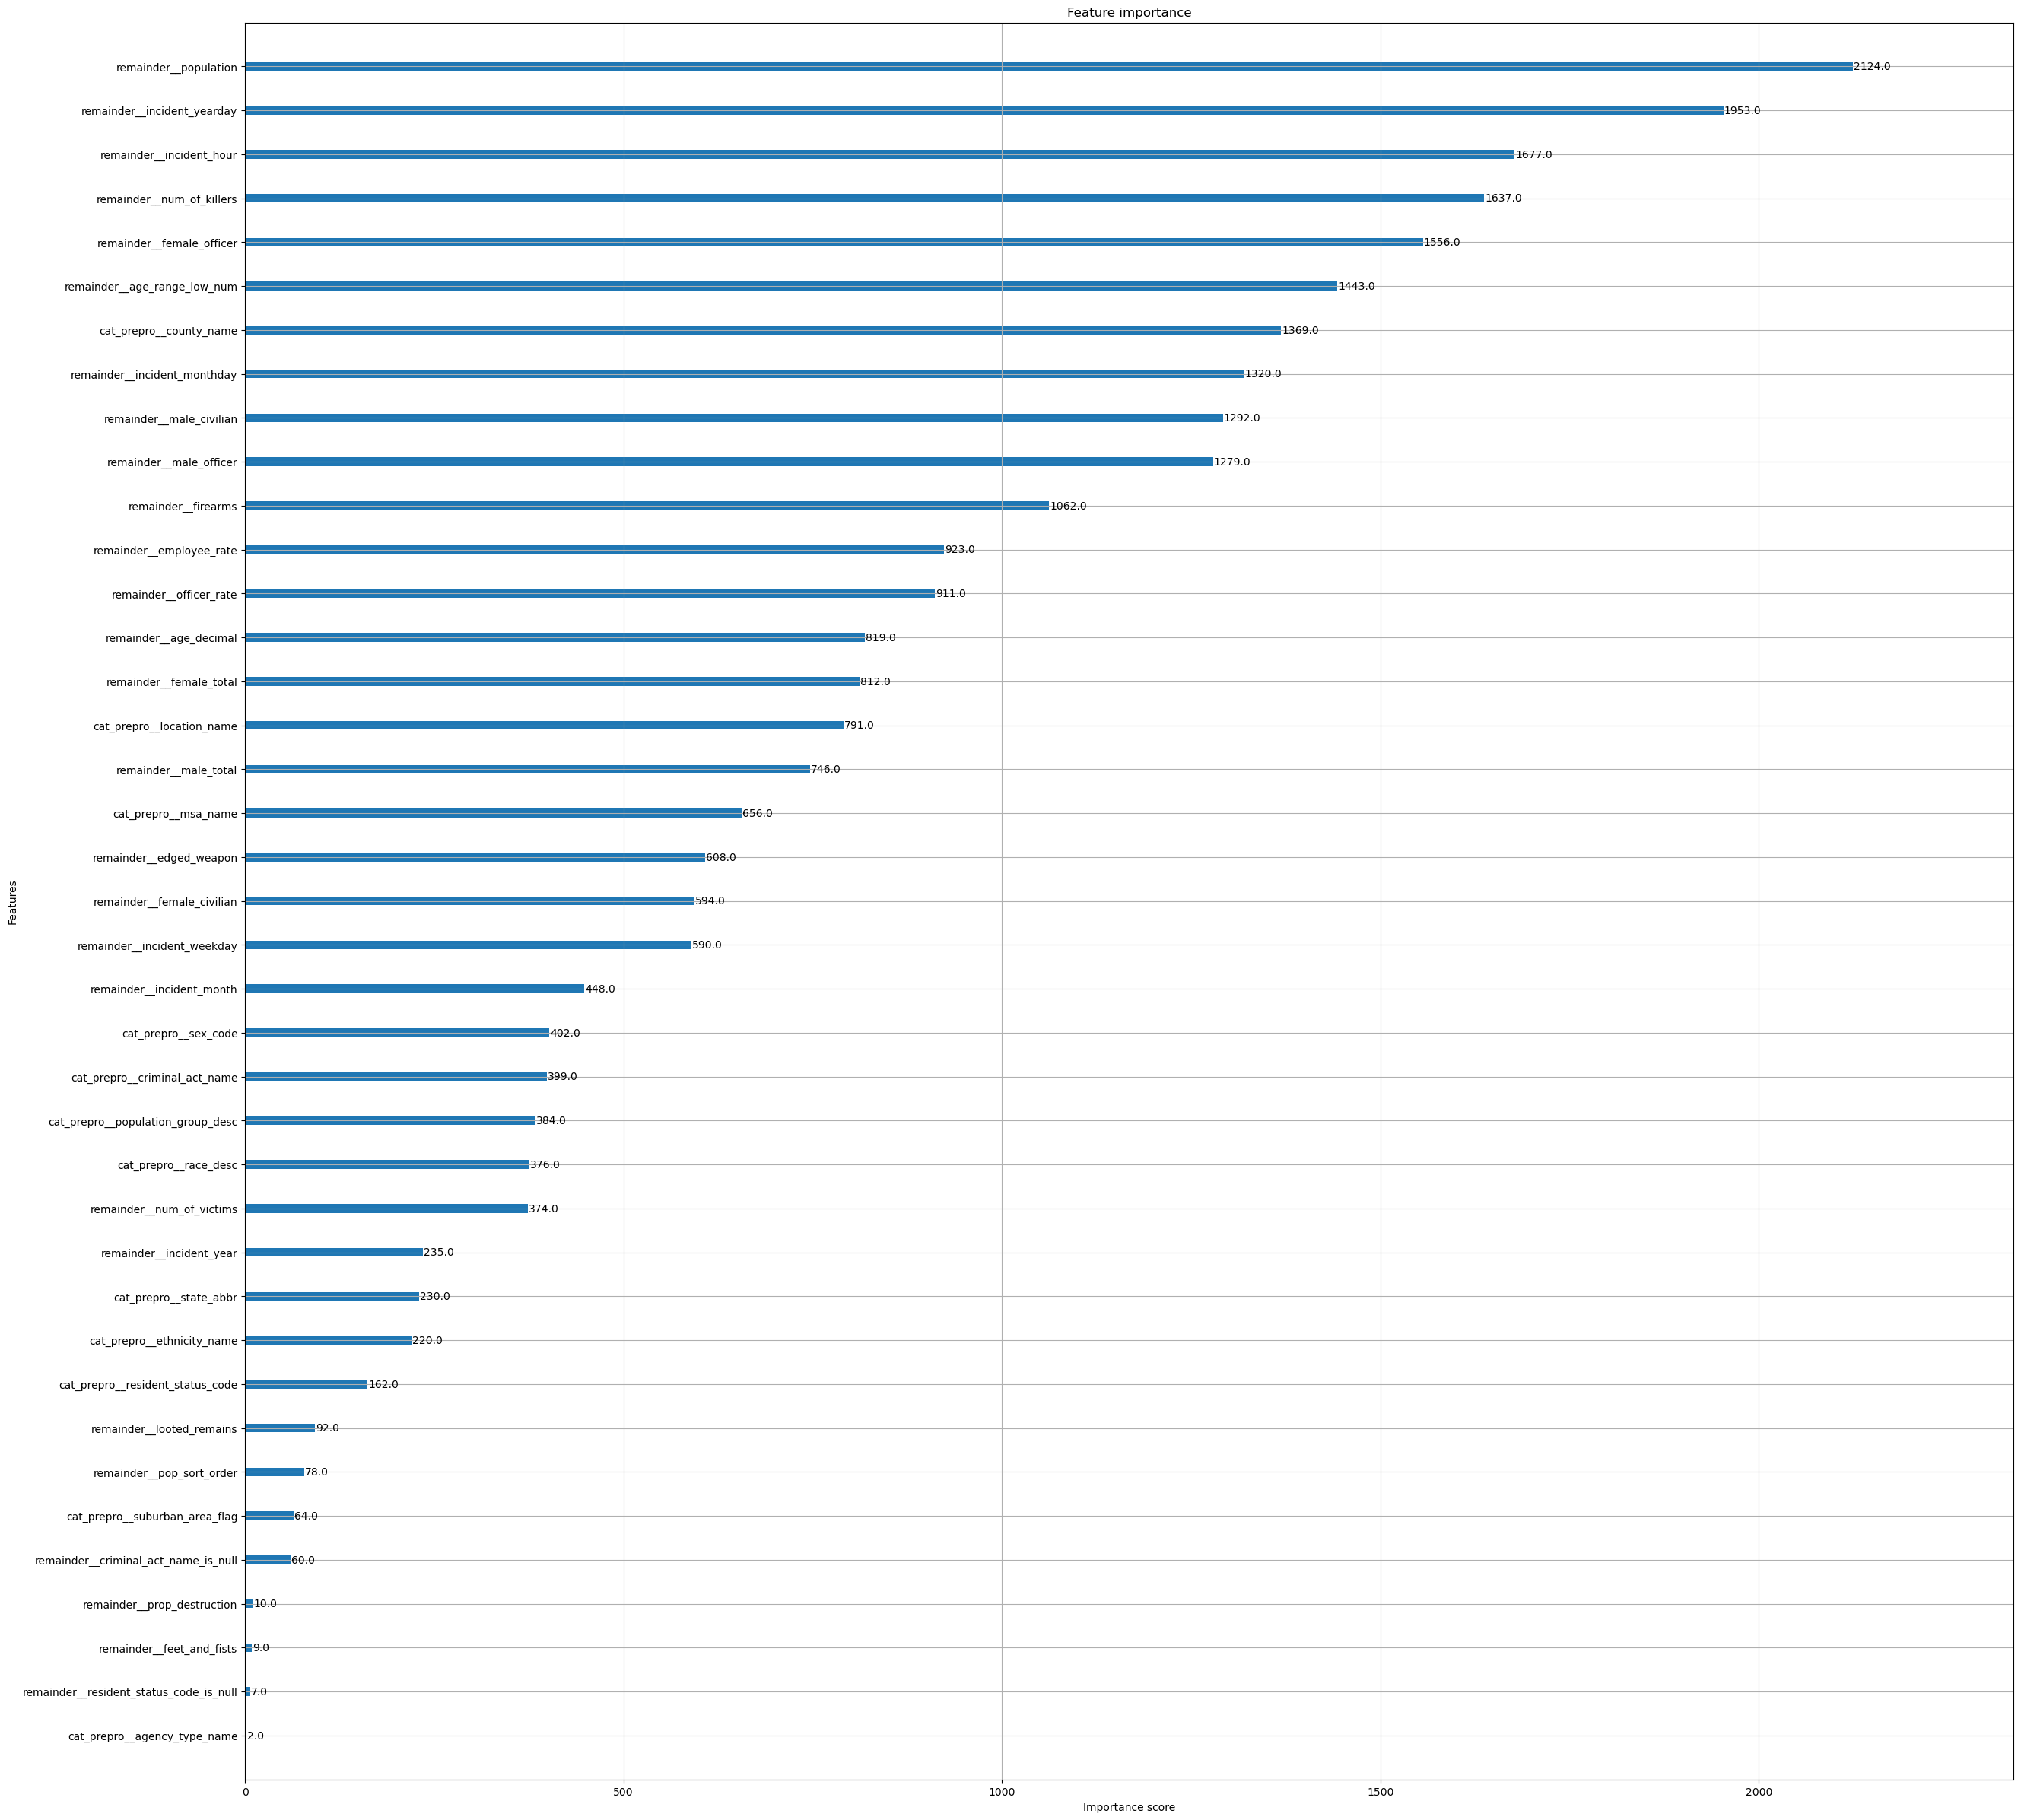

In [ ]:
#purely for curiosity's sake
feature_labels = halvesearch_cal2.best_estimator_.named_steps['columntransformer'].get_feature_names_out().tolist()
halvesearch_cal2.best_estimator_.named_steps['calibratedclassifiercv'].calibrated_classifiers_[0].estimator.get_booster().feature_names = feature_labels

fig, ax = plt.subplots(figsize=(30, 30))

plot_importance(halvesearch_cal2.best_estimator_.named_steps['calibratedclassifiercv'].calibrated_classifiers_[0].estimator.get_booster(),importance_type="weight",max_num_features=len(feature_labels),ax=ax)

plt.show()